In [3]:
from transformers import AutoTokenizer, AutoModel
import torch

In [5]:
model_name = "distilbert-base-uncased"

In [6]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [7]:
print(tokenizer.vocab_size)
print(tokenizer.model_max_length)

30522
512


In [8]:
text = "This movie was absolutely amazing!"

In [9]:
tokens = tokenizer(text)
print(tokens)

{'input_ids': [101, 2023, 3185, 2001, 7078, 6429, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}


In [10]:
input_ids = tokens["input_ids"]
print(f"Кол-во токенов {len(input_ids)}")

Кол-во токенов 8


In [11]:
decoded = tokenizer.decode(input_ids)
print(f"Decoded: {decoded}")

Decoded: [CLS] this movie was absolutely amazing! [SEP]


In [12]:
def tokenize_texts(texts, max_length=128):
    return tokenizer(
        texts,
        padding=True,
        max_length=max_length,
        return_tensors="pt"
    )

In [13]:
texts = [
    "This movie was great!",
    "Terrible movie, waste of time."
]

tokens = tokenize_texts(texts)
print(f"Shape: {tokens["input_ids"].shape}")

Shape: torch.Size([2, 9])


/home/semyon/miniconda3/envs/transformers_pet/lib/python3.14/site-packages/transformers/tokenization_utils_base.py:2355: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


In [14]:
print(f"Attention mask: {tokens["attention_mask"]}")

Attention mask: tensor([[1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1]])


In [15]:
print(f"CLS Token: {tokenizer.cls_token} (ID: {tokenizer.cls_token_id})")
print(f"SEP Token: {tokenizer.sep_token} (ID: {tokenizer.cls_token_id})")
print(f"PAD Token: {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})")

CLS Token: [CLS] (ID: 101)
SEP Token: [SEP] (ID: 101)
PAD Token: [PAD] (ID: 0)


In [16]:
single = tokenizer(text, return_tensors="pt")
print(f"Inupt IDs: {single["input_ids"]}")
print(f"Decoded: {tokenizer.decode(single["input_ids"][0])}")

Inupt IDs: tensor([[ 101, 2023, 3185, 2001, 7078, 6429,  999,  102]])
Decoded: [CLS] this movie was absolutely amazing! [SEP]


In [17]:
def explain_tokenization(text, tokenizer):
    tokens = tokenizer.tokenize(text)
    ids = tokenizer.convert_tokens_to_ids(tokens)

    print(f"Text: {text}")
    print(f"Tokens: {tokens}")
    print(f"IDs: {ids}")
    print(f"Length: {len(tokens)}")

explain_tokenization(texts[0], tokenizer)

Text: This movie was great!
Tokens: ['this', 'movie', 'was', 'great', '!']
IDs: [2023, 3185, 2001, 2307, 999]
Length: 5


### Embeddings

In [18]:
model = AutoModel.from_pretrained(model_name)

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 5117.31it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [19]:
model.eval()

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=Tru

In [20]:
print(model)

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=Tru

In [21]:
tokens = tokenizer(texts[0], return_tensors="pt")

In [22]:
with torch.no_grad():
    output = model(**tokens)

In [24]:
print(type(output))

<class 'transformers.modeling_outputs.BaseModelOutput'>


In [25]:
print(output.last_hidden_state.shape)

torch.Size([1, 7, 768])


In [26]:
cls_embedding = output.last_hidden_state[:, 0, :]
print(f"Shape: {cls_embedding.shape}")
print(f"CLS Embedding: {cls_embedding[0][:5]}")

Shape: torch.Size([1, 768])
CLS Embedding: tensor([ 0.0649, -0.1029,  0.2067, -0.0539, -0.1055])


In [27]:
def get_embeddings(texts, tokenizer, model, batch_size=32):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        tokens = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors = "pt"
        )

        with torch.no_grad():
            outputs = model(**tokens)

        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())

        import numpy as np
        return np.vstack(all_embeddings)

In [28]:
texts.append("Pretty good, I liked it.")
texts.append("Boring and too long.")

In [30]:
embeddings = get_embeddings(texts, tokenizer, model)
print(f"Embeddings shape: {embeddings.shape}")


Embeddings shape: (4, 768)


In [32]:
from sklearn.metrics.pairwise import cosine_similarity

def similarity(text1, text2, tokenizer, model):
    emb = get_embeddings([text1, text2], tokenizer, model)
    sim = cosine_similarity(emb[0: 1], emb[1:2])[0][0]
    return sim

In [36]:
sim1 = similarity("Great movie!", "Amazing film!", tokenizer, model)
sim2 = similarity("Great movie!", "Terrible film!", tokenizer, model)

print(f"Similary: {sim1:.3f}")
print(f"Not Similary: {sim2:.3f}")

Similary: 0.995
Not Similary: 0.984


### Attention

In [37]:
model = AutoModel.from_pretrained(
    model_name,
    output_attentions=True
)
model.eval()

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 4959.92it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=Tru

In [38]:
tokens = tokenizer(texts[0], return_tensors="pt")

In [39]:
with torch.no_grad():
    outputs = model(**tokens)

In [40]:
print(outputs.attentions[0])
print(f"Layers: {len(outputs.attentions)}")
print(f"Attention shape for 1st layer: {outputs.attentions[0].shape}")

tensor([[[[8.9366e-02, 1.2144e-01, 1.1435e-01, 9.3478e-02, 7.6462e-02,
           1.0850e-01, 3.9641e-01],
          [2.6456e-01, 7.3445e-02, 8.3450e-02, 1.3412e-01, 7.2370e-02,
           2.8562e-01, 8.6436e-02],
          [1.4408e-01, 5.3836e-02, 7.8081e-02, 2.7331e-02, 1.0917e-01,
           3.8155e-01, 2.0595e-01],
          [2.4657e-01, 1.6689e-01, 4.2471e-02, 6.1586e-02, 9.3903e-02,
           3.3680e-01, 5.1778e-02],
          [2.5068e-01, 9.8710e-02, 2.6497e-01, 6.5044e-02, 5.6585e-02,
           2.0139e-01, 6.2621e-02],
          [2.6528e-01, 1.6413e-01, 1.1657e-01, 8.9307e-02, 1.2377e-01,
           6.9330e-02, 1.7162e-01],
          [2.3626e-01, 1.2936e-01, 4.2319e-02, 6.8013e-02, 8.4633e-02,
           1.1271e-01, 3.2670e-01]],

         [[9.7873e-01, 4.4122e-03, 1.3874e-03, 3.6857e-03, 3.6152e-03,
           1.8036e-03, 6.3667e-03],
          [9.9293e-03, 6.7472e-02, 3.6033e-01, 1.5034e-01, 2.1420e-01,
           1.4518e-01, 5.2555e-02],
          [1.5880e-02, 1.1959e-02, 

In [44]:
attention = outputs.attentions[0]

attn_single = attention[0, 0]
print(f"Single head shape: {attn_single.shape}")

Single head shape: torch.Size([7, 7])


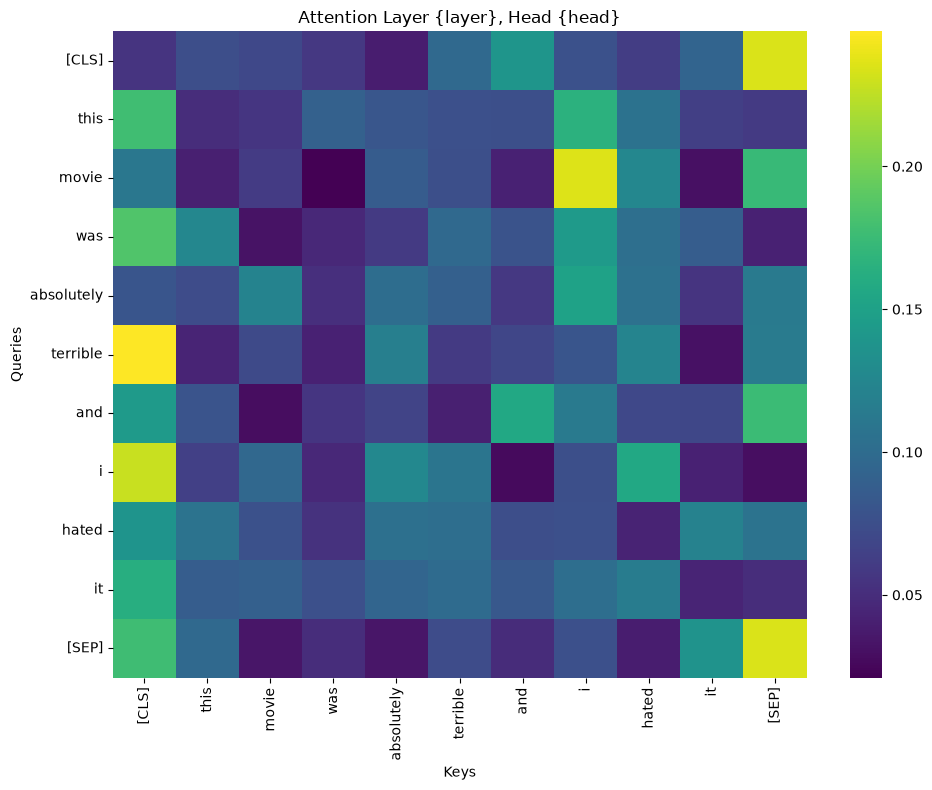

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_attention(tokens, attention, layer=0, head = 0):
    attn = attention[layer][0, head]

    token_list = tokenizer.convert_ids_to_tokens(tokens["input_ids"][0])

    plt.figure(figsize=(10,8))
    sns.heatmap(
        attn.cpu().numpy(),
        xticklabels=token_list,
        yticklabels=token_list,
        cmap="viridis",
        cbar=True
    )

    plt.title("Attention Layer {layer}, Head {head}")
    plt.xlabel("Keys")
    plt.ylabel("Queries")
    plt.tight_layout()
    plt.savefig("attention_layer{layer}_head{head}.png")
    plt.show()

visualize_attention(tokens, outputs.attentions, layer=0, head=0)

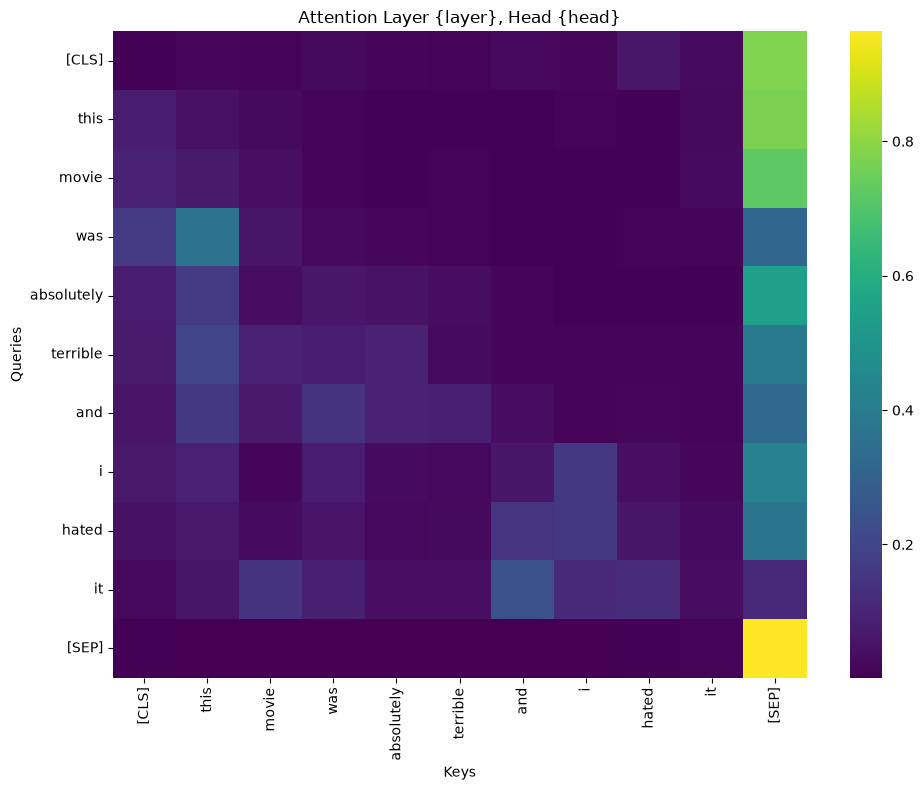

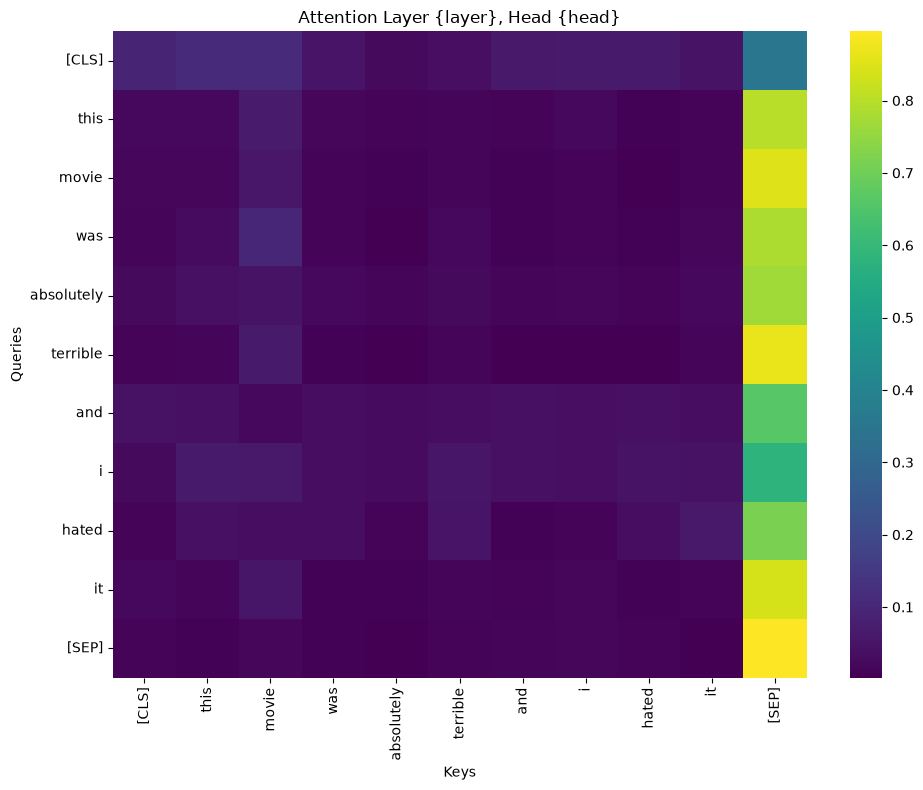

In [54]:
visualize_attention(tokens, outputs.attentions, layer=3, head=0)
visualize_attention(tokens, outputs.attentions, layer=5, head=0)

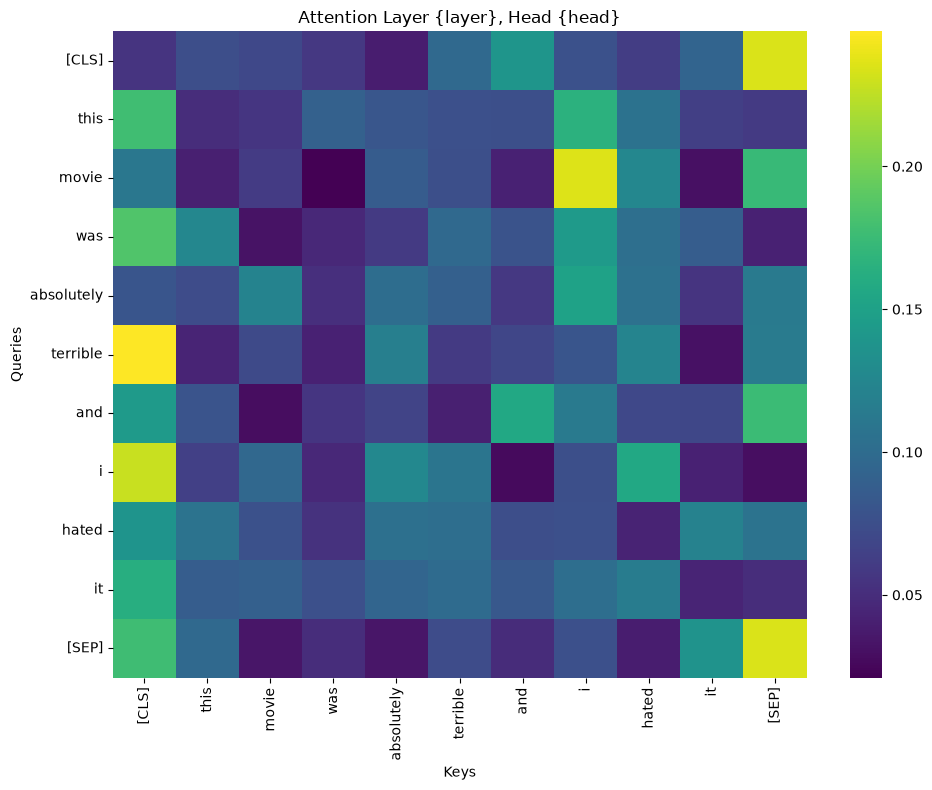

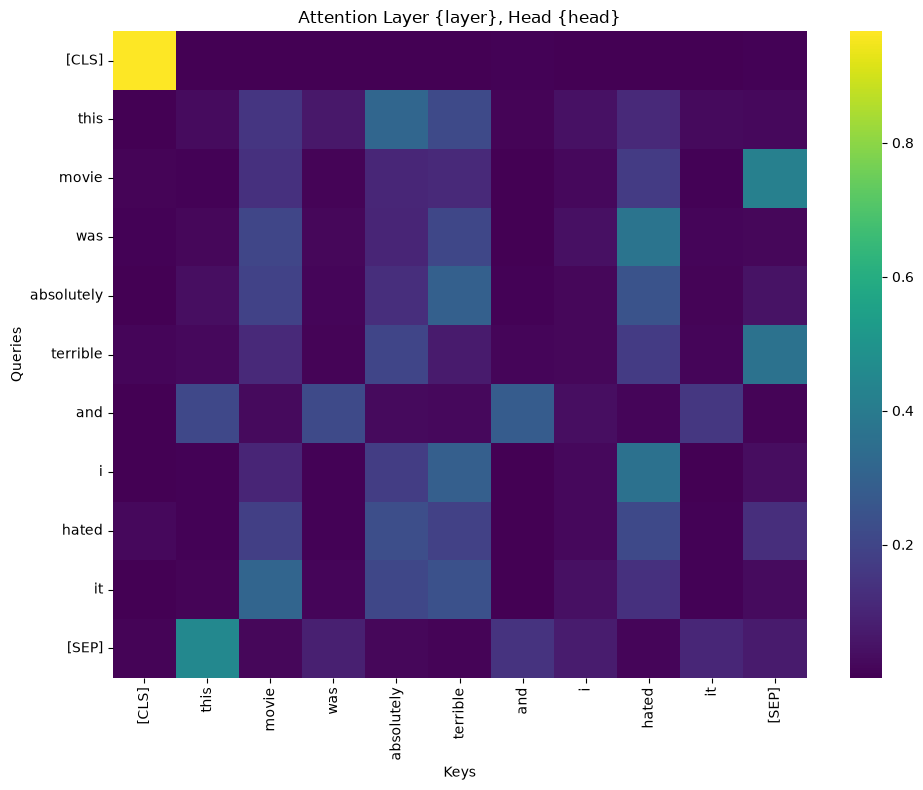

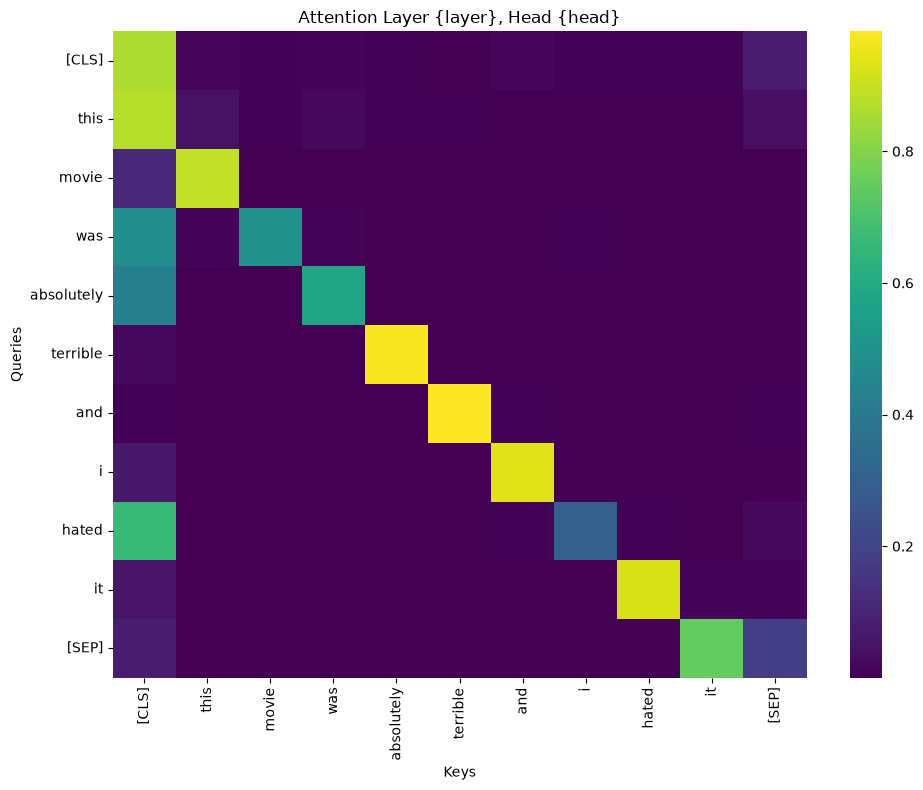

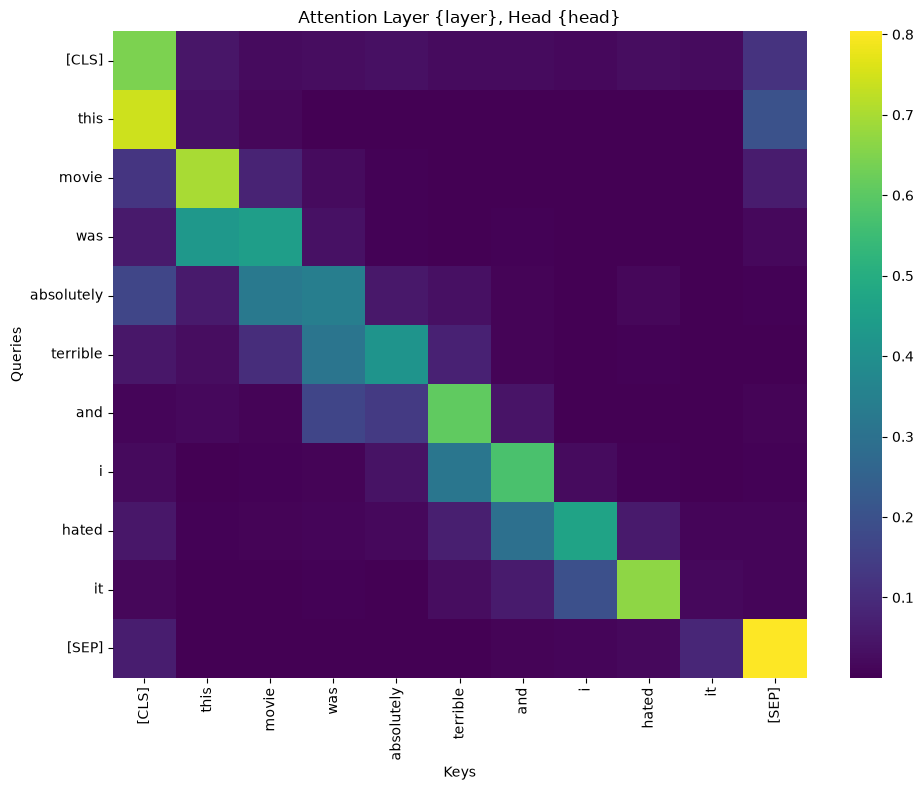

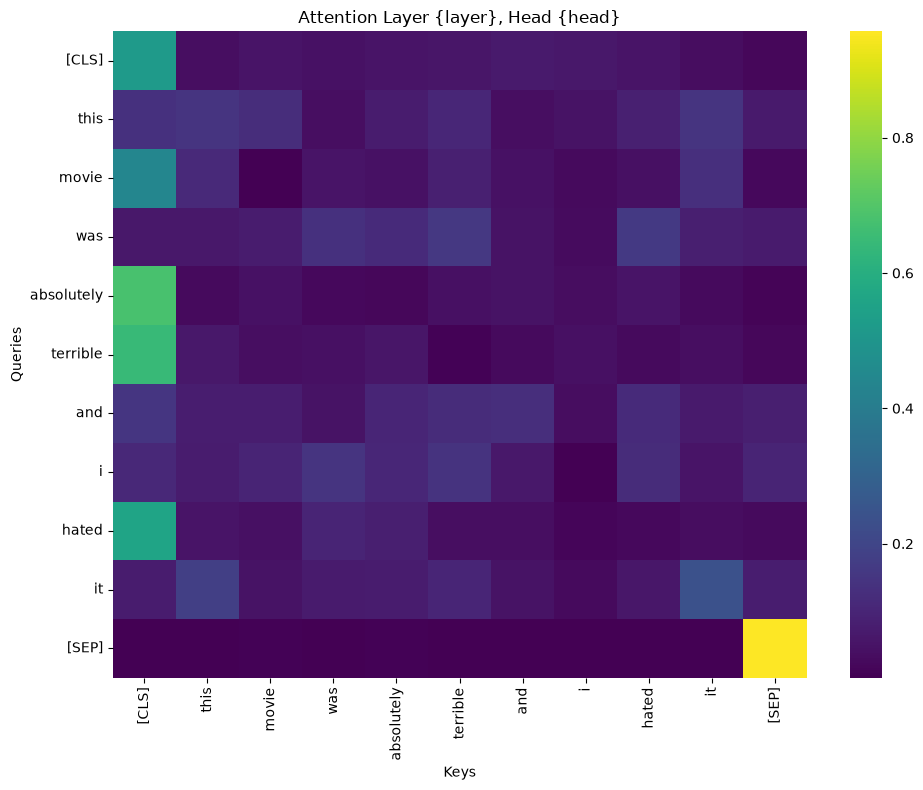

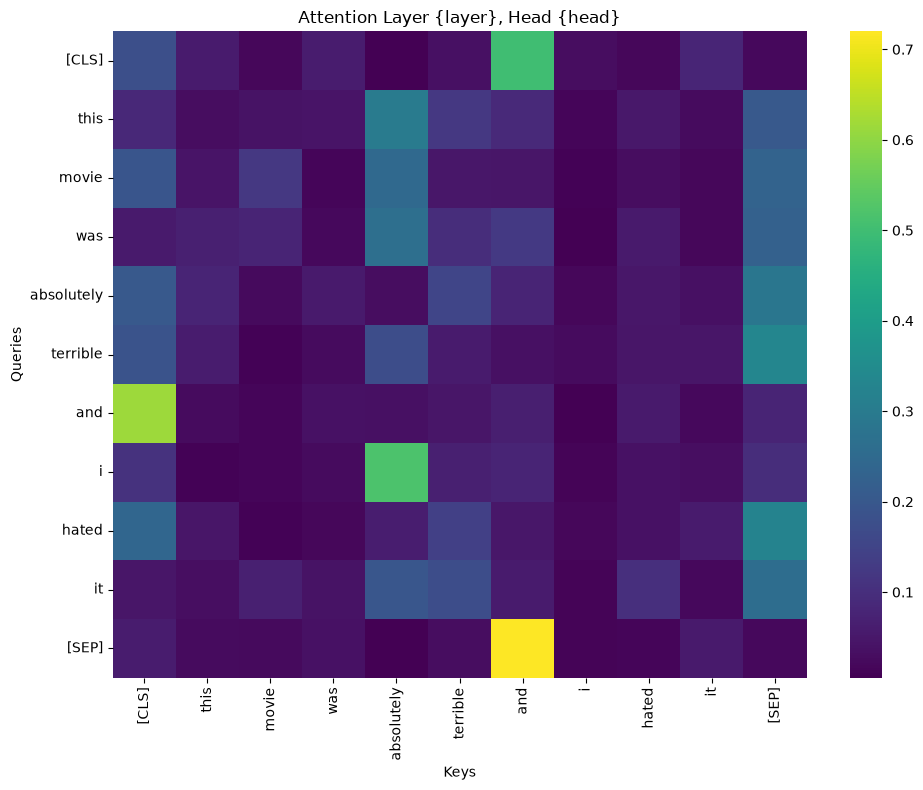

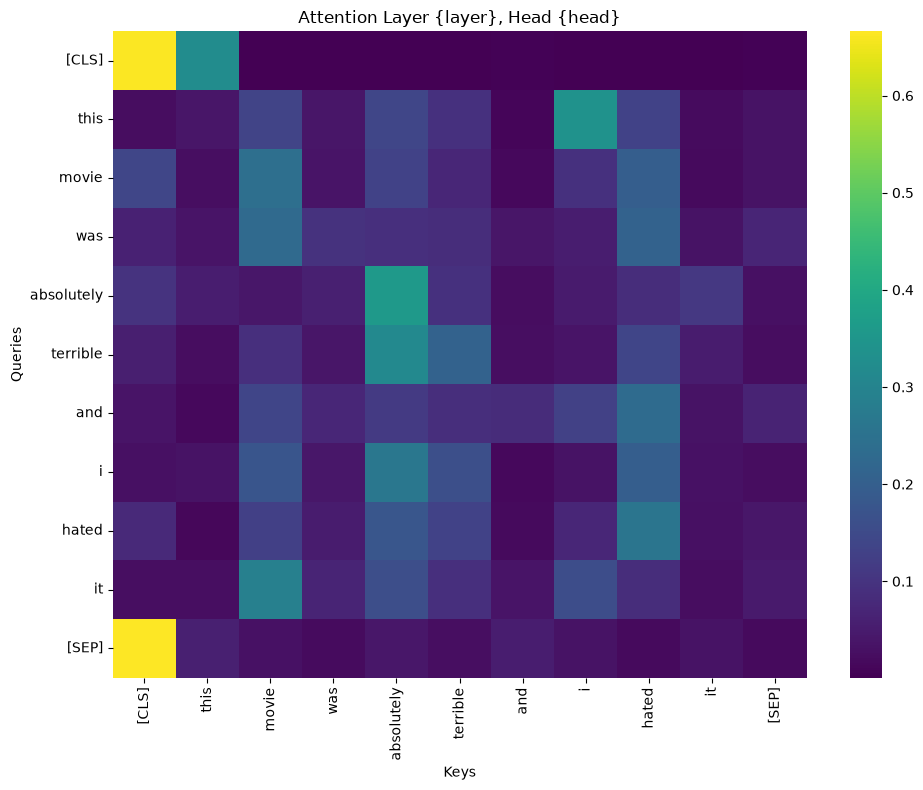

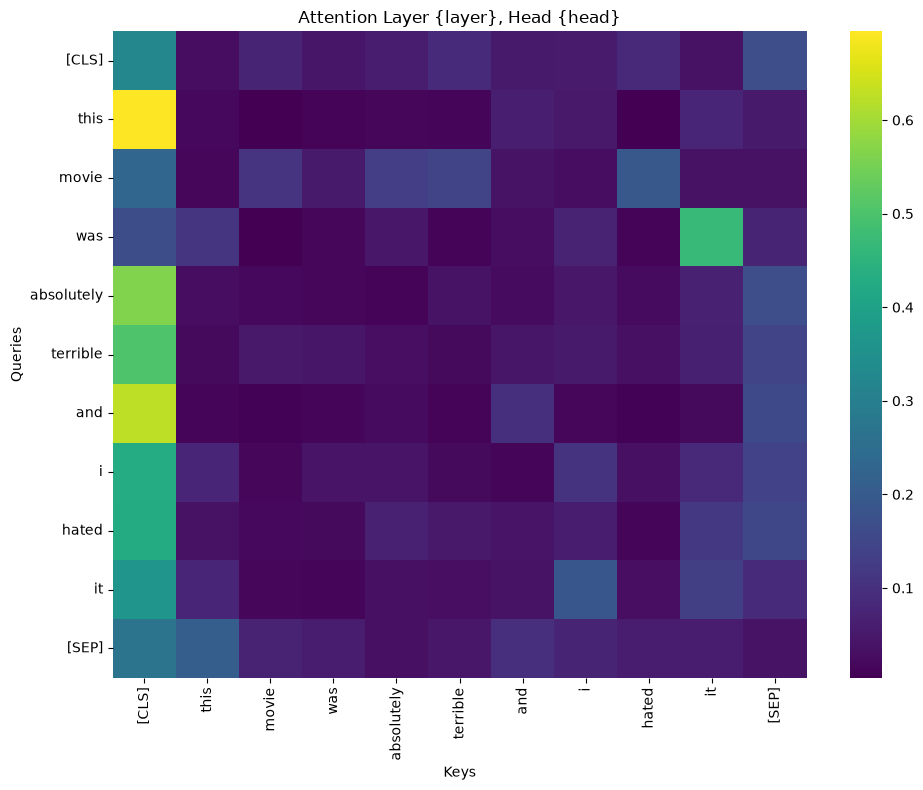

In [55]:
for head in range(8):
    visualize_attention(tokens, outputs.attentions, layer=0, head=head)

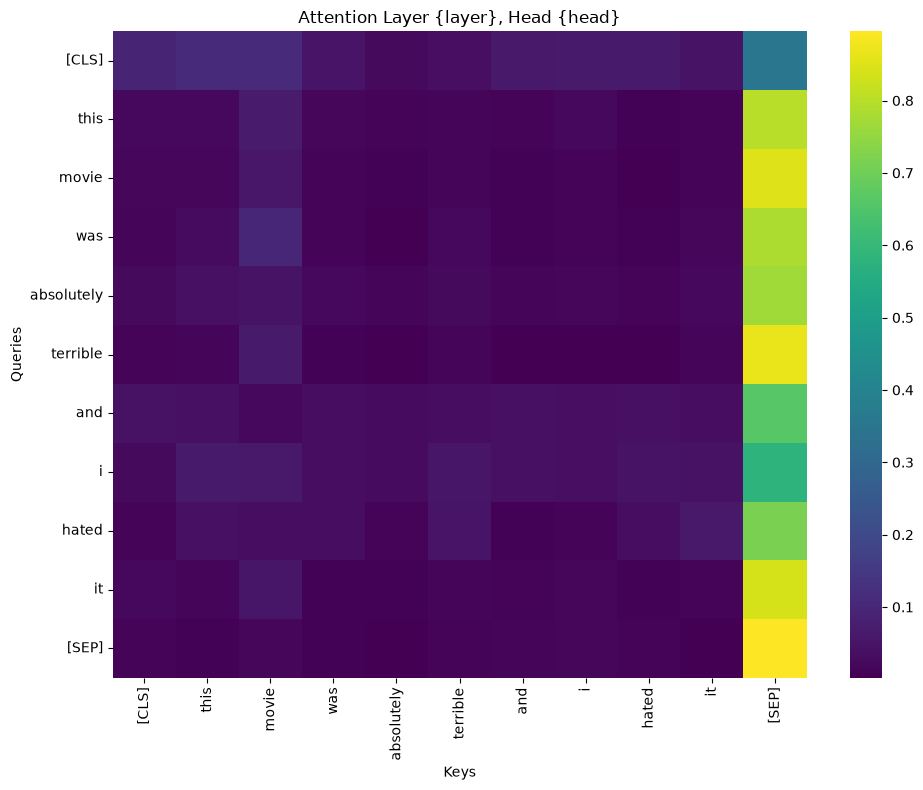

In [58]:
text = "This movie was absolutely terrible and I hated it"
tokens = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**tokens)

visualize_attention(tokens, outputs.attentions, layer=5, head=0)